# Spectral Analysis - UHI Data

Enhanced plotting and ROI management for transect cubes

In [18]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath("../"))
from utils.gref_pipeline.georef import *

sys.path.append(os.path.abspath("../../"))
from gref_pipeline import config

## Load and combine transect files

In [19]:
transect = load_transect(config.OUTPUT_FOLDER)
transect.list_files()


📋 Files in output (corrected=False):
 1. rad_uhi_20241029_115057_1  | shape=(1333, 968, 210)  | has_georef=True
 2. rad_uhi_20241029_115057_2  | shape=(1946, 968, 210)  | has_georef=True
 3. rad_uhi_20241029_115057_3  | shape=(2227, 968, 210)  | has_georef=True
 4. rad_uhi_20241029_115057_4  | shape=(2463, 968, 210)  | has_georef=True
 5. rad_uhi_20241029_115057_5  | shape=(2462, 968, 210)  | has_georef=True
 6. rad_uhi_20241029_115057_6  | shape=(155, 968, 210)  | has_georef=True


In [20]:
cube = transect.select_files(
    [
        # "rad_uhi_20241029_115057_4",
        "rad_uhi_20241029_115057_5",
    ]
)
cube.describe()

🔄 Rebuilding grids from georef hits for selected files...
   • rad_uhi_20241029_115057_5
  rad_uhi_20241029_115057_5: Using GRIDDED format (T=2462, S=968)
✅ Combined shapes: X/Y/Z (2462, 968), RGB (2462, 968)
🔄 Loading full hyperspectral cube...
   • Loading rad_uhi_20241029_115057_5...
✅ Loaded full cube: (2462, 968, 210) (T × S × B)

=== Combined_output ===
Tracks × Slits: 2462 × 968
RGB coverage: R/G/B finite ratios 1.00/1.00/1.00

📋 File boundaries:
  rad_uhi_20241029_115057_5: tracks 0–2461 (2462)


In [21]:
cube.adjust_uhi_alignment(dx=-0.05, dy=-3.0)

✅ UHI alignment adjusted:
   dx (East):  -0.050 m
   dy (North): -3.000 m

💡 This will be applied in plot_georef() with coordinate_system='NED'


In [22]:
cube.list_saved_corrections()


📋 Cached illumination corrections:

📁 File: rad_uhi_20241029_115057_5
   ✓ window=1000, strength=1.0
     Dataset: dataCube_illum_corrected_w1000_s1p00
     Shape: (2462, 968, 210), Size: 1909.2 MB
   ✓ window=500, strength=1.0
     Dataset: dataCube_illum_corrected_w500_s1p00
     Shape: (2462, 968, 210), Size: 1909.2 MB


In [6]:
cube.apply_illumination_correction_v2(window_size=500)

🔄 Using V2 algorithm (pandas rolling median)
✅ Illumination correction already applied with window=500, strength=1.0
   Loading from disk...
📂 Loading saved illumination correction from 1 files...
   rad_uhi_20241029_115057_5: window=500, strength=1.0
✅ Loaded illumination correction from disk


array([[[2.2304249e+00, 1.6764377e+00, 0.0000000e+00, ...,
         0.0000000e+00, 7.0077596e+00, 0.0000000e+00],
        [7.4757171e+00, 8.5974735e-01, 0.0000000e+00, ...,
         0.0000000e+00, 3.0958059e+00, 0.0000000e+00],
        [1.8294926e+00, 2.3438740e+00, 0.0000000e+00, ...,
         0.0000000e+00, 7.1090145e+00, 0.0000000e+00],
        ...,
        [1.7213115e+00, 1.4317783e+00, 0.0000000e+00, ...,
         1.0000000e+00, 2.3279436e-02, 3.7040919e-01],
        [5.8812752e+00, 2.0123754e+00, 0.0000000e+00, ...,
         0.0000000e+00, 1.4956644e+00, 0.0000000e+00],
        [2.3867478e+00, 1.0000000e+00, 0.0000000e+00, ...,
         0.0000000e+00, 1.5736811e+01, 4.5105180e-01]],

       [[2.2304249e+00, 7.7452070e-01, 3.9940205e+00, ...,
         0.0000000e+00, 0.0000000e+00, 9.6023534e-05],
        [1.7471981e+00, 0.0000000e+00, 1.2654871e+00, ...,
         0.0000000e+00, 8.5029960e-01, 6.3767982e-01],
        [1.9216584e+00, 0.0000000e+00, 3.0771544e+00, ...,
         0.000

In [7]:
stop

NameError: name 'stop' is not defined

In [ ]:
%matplotlib inline

💡 Interactive mode: Click on the plot to display coordinates


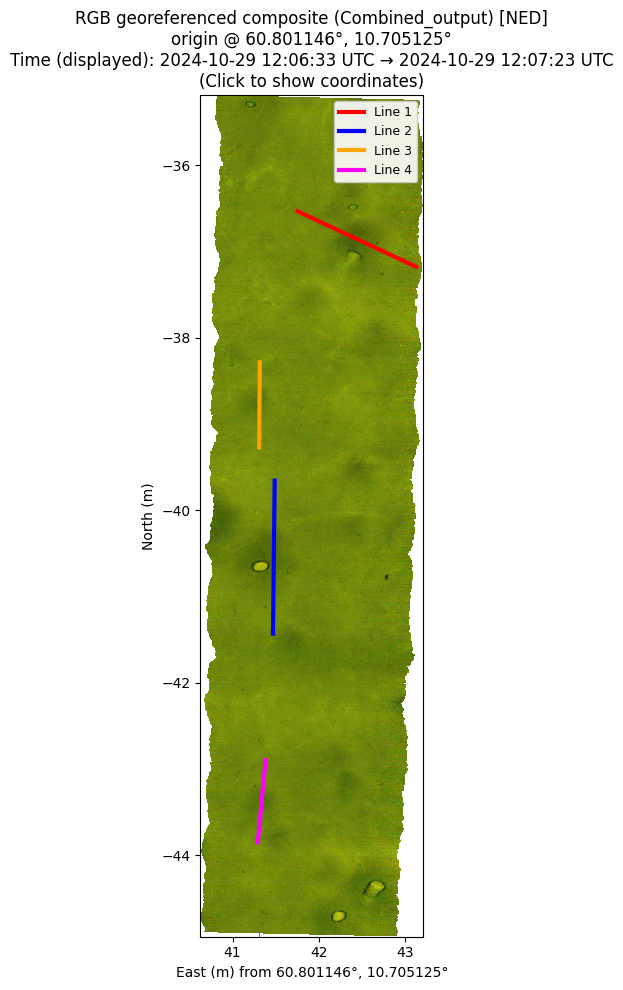

In [ ]:
# Define analysis lines
line1 = [(410, 710), (940, 770)]
line2 = [(340, 1030), (340, 1210)]
line3 = [(250, 890), (250, 990)]
line4 = [(300, 1358), (300, 1458)]

lines = [line1, line2, line3, line4]
colors = ["red", "blue", "orange", "magenta"]
labels = ["Line 1", "Line 2", "Line 3", "Line 4"]


cube.plot_georef(
    perimeter_line=lines,
    line_colors=["red", "blue", "orange", "magenta"],
    line_width=3,
    line_labels=[f"Line {i+1}" for i in range(len(lines))],
    use_corrected=True,
    coordinate_system="NED",
    track_start=config.UHI_TRACK_RANGE_5[0],
    track_end=config.UHI_TRACK_RANGE_5[1],
    figsize=(30, 10),
    apply_alignment_shift=True,
)

## Intensity profiles along lines

📊 Auto-calculated moving average window: 106 samples (20% of 531 samples)


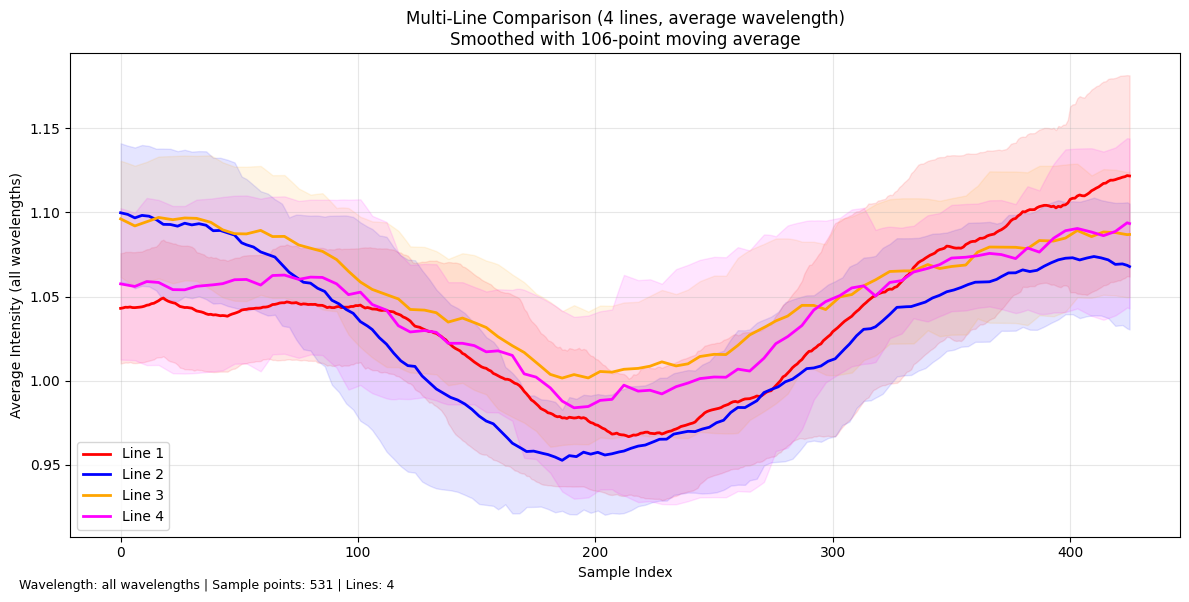

{'wavelength': 'all wavelengths',
 'wavelength_method': 'average',
 'smoothing_window': 106,
 'number_of_lines': 4,
 'sample_points': 531,
 'normalized': False,
 'normalization_method': None,
 'lines': [{'line_index': 1,
   'start_point': (410, 710),
   'end_point': (940, 770),
   'sample_indices': array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
           13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
           26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
           39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
           52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
           65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
           78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
           91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103,
          104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116,
          117, 118, 119, 120

In [ ]:
# Raw intensity profiles
cube.plot_line_intensity_profile(
    perimeter_line=lines,
    use_average=True,
    # moving_average_window=50,
    moving_average_percent=20,
    show_markers=False,
    line_labels=labels,
    line_colors=colors,
    use_corrected=True,
)

📊 Auto-calculated moving average window: 106 samples (20% of 531 samples)


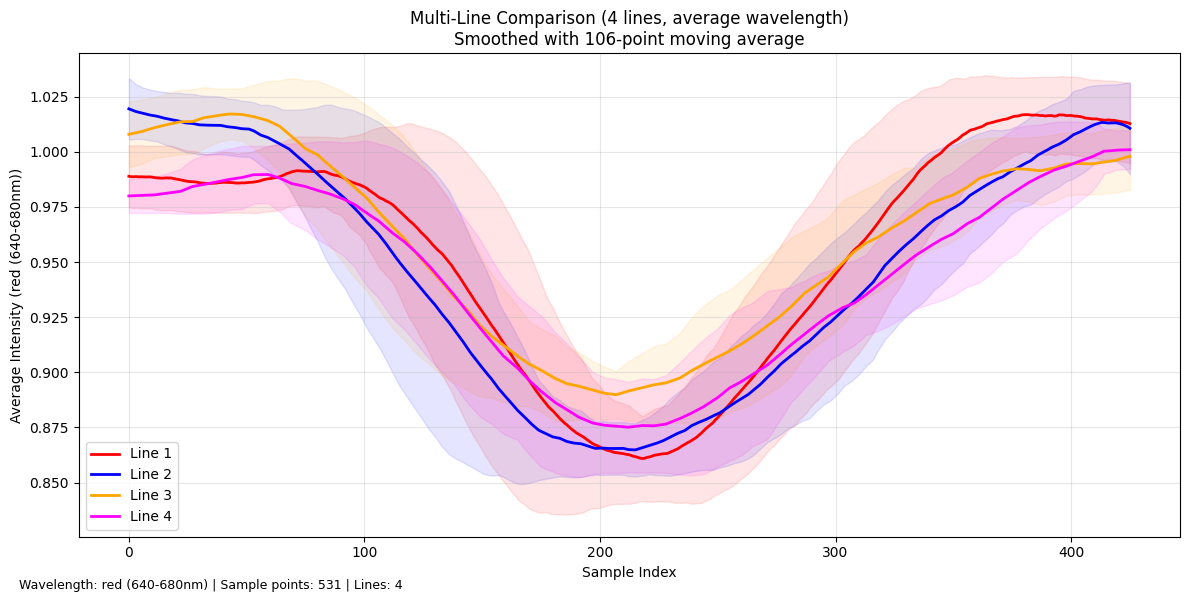

{'wavelength': 'red (640-680nm)',
 'wavelength_method': 'average',
 'smoothing_window': 106,
 'number_of_lines': 4,
 'sample_points': 531,
 'normalized': False,
 'normalization_method': None,
 'lines': [{'line_index': 1,
   'start_point': (410, 710),
   'end_point': (940, 770),
   'sample_indices': array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
           13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
           26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
           39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
           52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
           65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
           78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
           91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103,
          104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116,
          117, 118, 119, 120

In [ ]:
# Raw intensity profiles
cube.plot_line_intensity_profile(
    perimeter_line=lines,
    use_average=True,
    # moving_average_window=50
    moving_average_percent=20,
    show_markers=False,
    line_labels=labels,
    line_colors=colors,
    use_corrected=True,
    wavelength_range="red",  # Red bands (640-680nm)
    # wavelength_range='green'    # Green bands (520-580nm)
    # wavelength_range='blue'     # Blue bands (420-480nm)
    # wavelength_range='all'      # All ~200 wavelengths (default)
    # wavelength_range=(500, 600) # Custom range (500-600nm)
)

📊 Auto-calculated moving average window: 106 samples (20% of 531 samples)


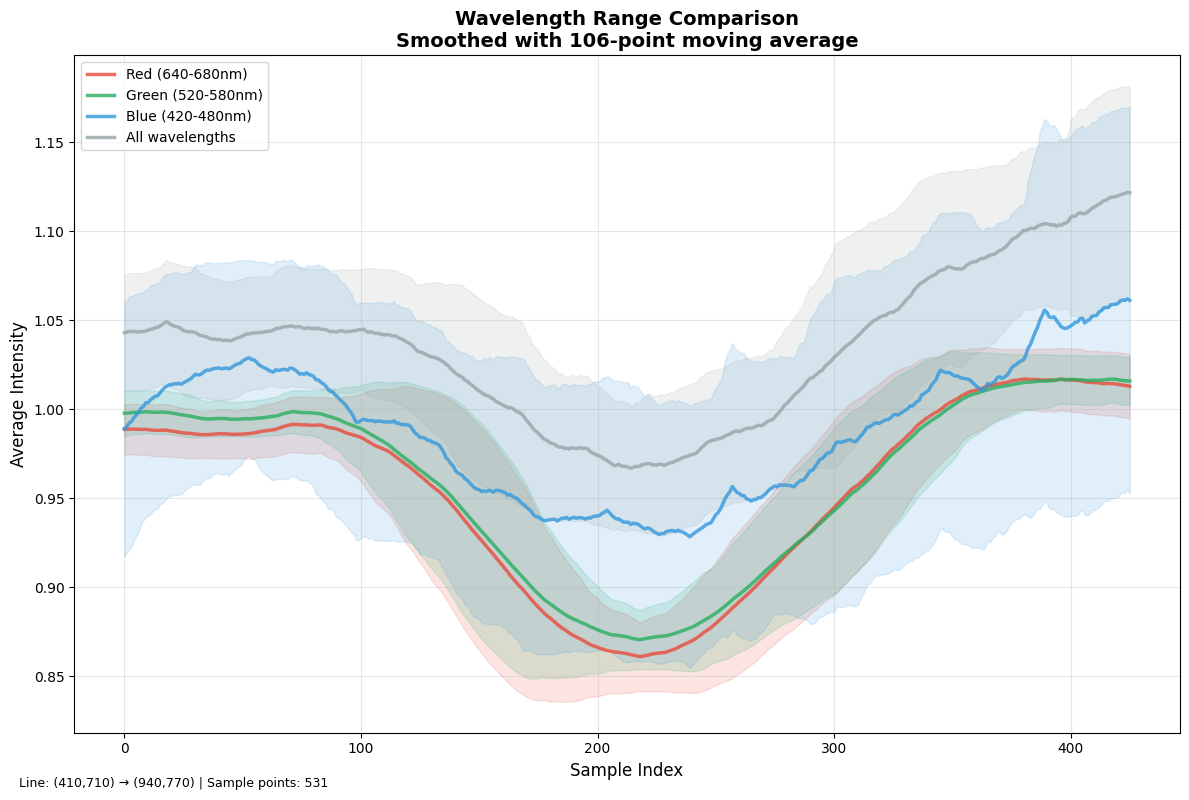

In [ ]:
cube.plot_wavelength_comparison(
    line=lines[0],  # Pick which line
    # line=lines[1],  # Pick which line
    # line=lines[2],  # Pick which line
    # line=lines[3],  # Pick which line
    wavelength_ranges=["red", "green", "blue", "all"],
    # moving_average_window=50,
    moving_average_percent=20,
    use_corrected=True,
)

## Interactive ROI selection

**Controls:**
- Left click: Add pixel
- Right click: Remove pixel
- Close window: Save ROI

In [ ]:
stop

In [25]:
%matplotlib qt

In [ ]:
# Create ROIs interactively
cube.plot_interactive_rgb(roi_name="sed1", use_corrected=True, marker_size=3)

✨ Creating new ROI 'sed1'


[]

c:\conda_envs\my_env\lib\site-packages\ipykernel\eventloops.py:145: UserWarning: Glyph 128433 (\N{THREE BUTTON MOUSE}) missing from font(s) DejaVu Sans.
  el.exec() if hasattr(el, "exec") else el.exec_()


In [ ]:
cube.plot_interactive_rgb(roi_name="dark1", use_corrected=True, marker_size=3)

✨ Creating new ROI 'dark1'


[]

c:\conda_envs\my_env\lib\site-packages\ipykernel\eventloops.py:145: UserWarning: Glyph 128433 (\N{THREE BUTTON MOUSE}) missing from font(s) DejaVu Sans.
  el.exec() if hasattr(el, "exec") else el.exec_()


✅ Added pixel: (slit=695, track=752) - Total: 1
✅ Added pixel: (slit=692, track=750) - Total: 2
✅ Added pixel: (slit=685, track=748) - Total: 3
✅ Added pixel: (slit=673, track=748) - Total: 4
✅ Added pixel: (slit=664, track=749) - Total: 5
✅ Added pixel: (slit=645, track=747) - Total: 6
✅ Added pixel: (slit=643, track=747) - Total: 7
✅ Added pixel: (slit=654, track=739) - Total: 8
✅ Added pixel: (slit=667, track=737) - Total: 9
✅ Added pixel: (slit=679, track=735) - Total: 10
✅ Added pixel: (slit=696, track=732) - Total: 11
✅ Added pixel: (slit=711, track=730) - Total: 12
✅ Added pixel: (slit=719, track=731) - Total: 13
✅ Added pixel: (slit=724, track=734) - Total: 14
✅ Added pixel: (slit=729, track=736) - Total: 15
✅ Added pixel: (slit=729, track=741) - Total: 16
✅ Added pixel: (slit=720, track=744) - Total: 17
✅ Added pixel: (slit=708, track=746) - Total: 18
✅ Added pixel: (slit=694, track=746) - Total: 19
✅ Added pixel: (slit=687, track=743) - Total: 20
✅ Added pixel: (slit=679, tra

In [ ]:
cube.plot_interactive_rgb(roi_name="dark2", use_corrected=True, marker_size=3)

✨ Creating new ROI 'dark2'


[]

✅ Added pixel: (slit=295, track=1119) - Total: 1
✅ Added pixel: (slit=306, track=1119) - Total: 2
✅ Added pixel: (slit=314, track=1120) - Total: 3
✅ Added pixel: (slit=319, track=1120) - Total: 4
✅ Added pixel: (slit=327, track=1119) - Total: 5
✅ Added pixel: (slit=335, track=1117) - Total: 6
✅ Added pixel: (slit=337, track=1114) - Total: 7
✅ Added pixel: (slit=341, track=1112) - Total: 8
✅ Added pixel: (slit=344, track=1110) - Total: 9
✅ Added pixel: (slit=349, track=1104) - Total: 10
✅ Added pixel: (slit=351, track=1099) - Total: 11
✅ Added pixel: (slit=349, track=1097) - Total: 12
✅ Added pixel: (slit=338, track=1094) - Total: 13
✅ Added pixel: (slit=334, track=1094) - Total: 14
✅ Added pixel: (slit=318, track=1096) - Total: 15
✅ Added pixel: (slit=312, track=1097) - Total: 16
✅ Added pixel: (slit=302, track=1099) - Total: 17
✅ Added pixel: (slit=295, track=1100) - Total: 18
✅ Added pixel: (slit=289, track=1102) - Total: 19
✅ Added pixel: (slit=287, track=1103) - Total: 20
✅ Added p

In [26]:
cube.plot_interactive_rgb(roi_name="dark sediment", use_corrected=False, marker_size=3)

✨ Creating new ROI 'dark sediment'


[]

c:\conda_envs\my_env\lib\site-packages\ipykernel\eventloops.py:145: UserWarning: Glyph 128433 (\N{THREE BUTTON MOUSE}) missing from font(s) DejaVu Sans.
  el.exec() if hasattr(el, "exec") else el.exec_()


✅ Added pixel: (slit=258, track=936) - Total: 1
✅ Added pixel: (slit=260, track=936) - Total: 2
✅ Added pixel: (slit=263, track=936) - Total: 3
✅ Added pixel: (slit=275, track=934) - Total: 4
✅ Added pixel: (slit=280, track=935) - Total: 5
✅ Added pixel: (slit=285, track=938) - Total: 6
✅ Added pixel: (slit=285, track=939) - Total: 7
✅ Added pixel: (slit=281, track=942) - Total: 8
✅ Added pixel: (slit=272, track=943) - Total: 9
✅ Added pixel: (slit=263, track=944) - Total: 10
✅ Added pixel: (slit=258, track=943) - Total: 11
✅ Added pixel: (slit=256, track=937) - Total: 12
✅ Added pixel: (slit=262, track=934) - Total: 13
✅ Added pixel: (slit=266, track=931) - Total: 14
✅ Added pixel: (slit=276, track=931) - Total: 15
✅ Added pixel: (slit=287, track=936) - Total: 16
✅ Added pixel: (slit=294, track=940) - Total: 17
✅ Added pixel: (slit=294, track=943) - Total: 18
✅ Added pixel: (slit=290, track=945) - Total: 19
✅ Added pixel: (slit=273, track=947) - Total: 20
✅ Added pixel: (slit=261, tra

In [ ]:
cube.plot_interactive_rgb(roi_name="dark_collected", use_corrected=True, marker_size=3)

✨ Creating new ROI 'dark_collected'


[]

✅ Added pixel: (slit=626, track=751) - Total: 1
✅ Added pixel: (slit=631, track=747) - Total: 2
✅ Added pixel: (slit=642, track=747) - Total: 3
✅ Added pixel: (slit=656, track=749) - Total: 4
✅ Added pixel: (slit=669, track=750) - Total: 5
✅ Added pixel: (slit=690, track=752) - Total: 6
✅ Added pixel: (slit=700, track=752) - Total: 7
✅ Added pixel: (slit=719, track=750) - Total: 8
✅ Added pixel: (slit=733, track=743) - Total: 9
✅ Added pixel: (slit=736, track=737) - Total: 10
✅ Added pixel: (slit=725, track=733) - Total: 11
✅ Added pixel: (slit=696, track=733) - Total: 12
✅ Added pixel: (slit=673, track=734) - Total: 13
✅ Added pixel: (slit=657, track=738) - Total: 14
✅ Added pixel: (slit=639, track=743) - Total: 15
✅ Added pixel: (slit=641, track=744) - Total: 16
✅ Added pixel: (slit=684, track=743) - Total: 17
✅ Added pixel: (slit=716, track=742) - Total: 18
✅ Added pixel: (slit=715, track=737) - Total: 19
✅ Added pixel: (slit=668, track=735) - Total: 20
✅ Added pixel: (slit=664, tra

In [ ]:
cube.plot_interactive_rgb(roi_name="vertical", use_corrected=True, marker_size=1)

✨ Creating new ROI 'vertical'


[]

✅ Added pixel: (slit=315, track=1143) - Total: 1
✅ Added pixel: (slit=304, track=1128) - Total: 2
✅ Added pixel: (slit=304, track=1129) - Total: 3
✅ Added pixel: (slit=303, track=1129) - Total: 4
✅ Added pixel: (slit=303, track=1130) - Total: 5
✅ Added pixel: (slit=301, track=1131) - Total: 6
✅ Added pixel: (slit=300, track=1131) - Total: 7
✅ Added pixel: (slit=298, track=1132) - Total: 8
✅ Added pixel: (slit=299, track=1132) - Total: 9
✅ Added pixel: (slit=295, track=1133) - Total: 10
✅ Added pixel: (slit=297, track=1133) - Total: 11
✅ Added pixel: (slit=291, track=1135) - Total: 12
✅ Added pixel: (slit=224, track=1130) - Total: 13
✅ Added pixel: (slit=227, track=1130) - Total: 14
✅ Added pixel: (slit=229, track=1130) - Total: 15
✅ Added pixel: (slit=225, track=1129) - Total: 16
✅ Added pixel: (slit=227, track=1129) - Total: 17
✅ Added pixel: (slit=228, track=1129) - Total: 18
✅ Added pixel: (slit=228, track=1128) - Total: 19
✅ Added pixel: (slit=229, track=1128) - Total: 20
✅ Added p

In [ ]:
cube.plot_interactive_rgb(roi_name="vertical_inside", use_corrected=True, marker_size=1)

✨ Creating new ROI 'vertical_inside'


[]

✅ Added pixel: (slit=323, track=1122) - Total: 1
✅ Added pixel: (slit=287, track=1127) - Total: 2
✅ Added pixel: (slit=281, track=1127) - Total: 3
✅ Added pixel: (slit=277, track=1127) - Total: 4
✅ Added pixel: (slit=276, track=1127) - Total: 5
📌 Pixel already selected: (slit=276, track=1127)
📌 Pixel already selected: (slit=276, track=1127)
✅ Added pixel: (slit=265, track=1131) - Total: 6
✅ Added pixel: (slit=276, track=1130) - Total: 7
✅ Added pixel: (slit=277, track=1130) - Total: 8
✅ Added pixel: (slit=275, track=1129) - Total: 9
✅ Added pixel: (slit=270, track=1129) - Total: 10
✅ Added pixel: (slit=266, track=1129) - Total: 11
✅ Added pixel: (slit=262, track=1130) - Total: 12
✅ Added pixel: (slit=261, track=1131) - Total: 13
✅ Added pixel: (slit=262, track=1132) - Total: 14
✅ Added pixel: (slit=264, track=1133) - Total: 15
✅ Added pixel: (slit=267, track=1133) - Total: 16
✅ Added pixel: (slit=271, track=1133) - Total: 17
✅ Added pixel: (slit=276, track=1132) - Total: 18
✅ Added pix

In [ ]:
cube.plot_interactive_rgb(roi_name="vertical_inside", use_corrected=True, marker_size=1)

📂 Loaded 'vertical_inside' with 83 pixels


[(270, 1129),
 (285, 1129),
 (286, 1128),
 (323, 1122),
 (276, 1127),
 (267, 1133),
 (260, 1127),
 (271, 1133),
 (245, 1132),
 (256, 1132),
 (261, 1131),
 (275, 1130),
 (277, 1127),
 (263, 1131),
 (283, 1127),
 (261, 1133),
 (286, 1132),
 (266, 1129),
 (267, 1128),
 (258, 1134),
 (250, 1130),
 (282, 1128),
 (255, 1129),
 (278, 1133),
 (284, 1128),
 (250, 1132),
 (268, 1131),
 (265, 1132),
 (278, 1126),
 (284, 1130),
 (244, 1130),
 (268, 1133),
 (272, 1131),
 (274, 1128),
 (278, 1128),
 (290, 1129),
 (268, 1126),
 (260, 1131),
 (263, 1130),
 (274, 1130),
 (278, 1130),
 (262, 1131),
 (291, 1130),
 (268, 1128),
 (257, 1128),
 (260, 1133),
 (265, 1129),
 (264, 1133),
 (279, 1131),
 (263, 1134),
 (276, 1128),
 (270, 1130),
 (261, 1127),
 (253, 1132),
 (283, 1133),
 (275, 1129),
 (268, 1132),
 (276, 1130),
 (264, 1128),
 (248, 1129),
 (262, 1128),
 (253, 1134),
 (249, 1130),
 (260, 1130),
 (276, 1132),
 (288, 1131),
 (256, 1135),
 (270, 1134),
 (248, 1131),
 (262, 1130),
 (251, 1130),
 (277,

c:\conda_envs\my_env\lib\site-packages\ipykernel\eventloops.py:145: UserWarning: Glyph 128433 (\N{THREE BUTTON MOUSE}) missing from font(s) DejaVu Sans.
  el.exec() if hasattr(el, "exec") else el.exec_()


✅ Added pixel: (slit=324, track=1121) - Total: 84
✅ Added pixel: (slit=330, track=1119) - Total: 85
❌ Removed pixel: (slit=330, track=1119) - Total: 84
❌ Removed pixel: (slit=324, track=1121) - Total: 83
⚠️ Pixel not selected: (slit=324, track=1122)
⚠️ Pixel not selected: (slit=324, track=1123)
⚠️ Pixel not selected: (slit=324, track=1122)
❌ Removed pixel: (slit=323, track=1122) - Total: 82
⚠️ Pixel not selected: (slit=322, track=1122)
⚠️ Pixel not selected: (slit=321, track=1122)
💾 Saved ROI 'vertical_inside' with 82 pixels


In [ ]:
cube.plot_interactive_rgb(roi_name="tripple", use_corrected=True, marker_size=5)

📂 Loaded 'tripple' with 72 pixels


[(697, 595),
 (698, 594),
 (729, 566),
 (688, 595),
 (675, 595),
 (666, 595),
 (699, 595),
 (668, 596),
 (667, 597),
 (670, 596),
 (691, 597),
 (682, 594),
 (685, 596),
 (696, 596),
 (662, 597),
 (673, 597),
 (681, 595),
 (679, 595),
 (668, 595),
 (692, 595),
 (669, 596),
 (681, 598),
 (683, 595),
 (701, 595),
 (693, 597),
 (683, 598),
 (698, 593),
 (675, 594),
 (697, 594),
 (686, 594),
 (667, 596),
 (686, 597),
 (688, 594),
 (699, 594),
 (666, 597),
 (680, 596),
 (691, 596),
 (671, 596),
 (696, 595),
 (672, 595),
 (682, 596),
 (687, 597),
 (673, 596),
 (687, 595),
 (695, 596),
 (676, 598),
 (700, 595),
 (677, 597),
 (679, 596),
 (670, 597),
 (681, 597),
 (694, 597),
 (697, 596),
 (683, 597),
 (698, 595),
 (675, 596),
 (699, 596),
 (688, 596),
 (691, 595),
 (691, 598),
 (690, 596),
 (680, 595),
 (672, 594),
 (673, 595),
 (695, 595),
 (674, 597),
 (677, 596),
 (676, 597),
 (678, 594),
 (678, 597),
 (681, 596),
 (693, 595)]

⚠️ Pixel not selected: (slit=731, track=563)
⚠️ Pixel not selected: (slit=724, track=563)
⚠️ Pixel not selected: (slit=724, track=563)
⚠️ Pixel not selected: (slit=721, track=563)
⚠️ Pixel not selected: (slit=721, track=565)
⚠️ Pixel not selected: (slit=728, track=565)
⚠️ Pixel not selected: (slit=730, track=565)
⚠️ Pixel not selected: (slit=730, track=564)
⚠️ Pixel not selected: (slit=732, track=567)
✅ Added pixel: (slit=735, track=563) - Total: 73
⚠️ Pixel not selected: (slit=733, track=563)
⚠️ Pixel not selected: (slit=733, track=563)
⚠️ Pixel not selected: (slit=734, track=563)
⚠️ Pixel not selected: (slit=734, track=563)
⚠️ Pixel not selected: (slit=734, track=563)
⚠️ Pixel not selected: (slit=733, track=563)
⚠️ Pixel not selected: (slit=733, track=563)
⚠️ Pixel not selected: (slit=731, track=563)
⚠️ Pixel not selected: (slit=730, track=563)
⚠️ Pixel not selected: (slit=568, track=766)
⚠️ Click outside valid area
⚠️ Click outside valid area
⚠️ Click outside valid area
⚠️ Pixel not

In [ ]:
cube.plot_interactive_rgb(roi_name="tripple2", use_corrected=True, marker_size=1)

✨ Creating new ROI 'tripple2'


[]

✅ Added pixel: (slit=679, track=692) - Total: 1
⚠️ Pixel not selected: (slit=679, track=693)
⚠️ Pixel not selected: (slit=679, track=693)
⚠️ Pixel not selected: (slit=679, track=693)
⚠️ Pixel not selected: (slit=679, track=693)
⚠️ Pixel not selected: (slit=679, track=693)
⚠️ Pixel not selected: (slit=679, track=693)
⚠️ Pixel not selected: (slit=679, track=693)
⚠️ Pixel not selected: (slit=679, track=693)
⚠️ Pixel not selected: (slit=679, track=693)
⚠️ Pixel not selected: (slit=679, track=693)
⚠️ Pixel not selected: (slit=679, track=693)
⚠️ Pixel not selected: (slit=679, track=693)
⚠️ Pixel not selected: (slit=679, track=693)
⚠️ Pixel not selected: (slit=679, track=693)
⚠️ Pixel not selected: (slit=679, track=693)
⚠️ Pixel not selected: (slit=679, track=693)
⚠️ Pixel not selected: (slit=679, track=693)
⚠️ Pixel not selected: (slit=679, track=693)
⚠️ Pixel not selected: (slit=679, track=693)
⚠️ Pixel not selected: (slit=679, track=693)
⚠️ Pixel not selected: (slit=679, track=693)
⚠️ Pixe

In [ ]:
cube.plot_interactive_rgb(roi_name="tripple3", use_corrected=True, marker_size=1)

✨ Creating new ROI 'tripple3'


[]

✅ Added pixel: (slit=645, track=759) - Total: 1
✅ Added pixel: (slit=648, track=760) - Total: 2
✅ Added pixel: (slit=653, track=760) - Total: 3
✅ Added pixel: (slit=655, track=760) - Total: 4
✅ Added pixel: (slit=655, track=762) - Total: 5
✅ Added pixel: (slit=647, track=763) - Total: 6
✅ Added pixel: (slit=642, track=762) - Total: 7
✅ Added pixel: (slit=638, track=760) - Total: 8
✅ Added pixel: (slit=638, track=759) - Total: 9
📌 Pixel already selected: (slit=645, track=759)
✅ Added pixel: (slit=655, track=759) - Total: 10
✅ Added pixel: (slit=660, track=759) - Total: 11
✅ Added pixel: (slit=662, track=759) - Total: 12
✅ Added pixel: (slit=670, track=760) - Total: 13
📌 Pixel already selected: (slit=670, track=760)
✅ Added pixel: (slit=669, track=761) - Total: 14
✅ Added pixel: (slit=662, track=761) - Total: 15
✅ Added pixel: (slit=657, track=761) - Total: 16
✅ Added pixel: (slit=649, track=762) - Total: 17
✅ Added pixel: (slit=643, track=763) - Total: 18
✅ Added pixel: (slit=640, track

In [ ]:
cube.plot_interactive_rgb(roi_name="double1", use_corrected=True, marker_size=1)

✨ Creating new ROI 'double1'


[]

✅ Added pixel: (slit=854, track=1504) - Total: 1
✅ Added pixel: (slit=859, track=1505) - Total: 2
✅ Added pixel: (slit=866, track=1505) - Total: 3
✅ Added pixel: (slit=870, track=1505) - Total: 4
✅ Added pixel: (slit=872, track=1507) - Total: 5
✅ Added pixel: (slit=872, track=1508) - Total: 6
✅ Added pixel: (slit=858, track=1514) - Total: 7
✅ Added pixel: (slit=855, track=1514) - Total: 8
✅ Added pixel: (slit=851, track=1515) - Total: 9
✅ Added pixel: (slit=844, track=1515) - Total: 10
✅ Added pixel: (slit=838, track=1515) - Total: 11
✅ Added pixel: (slit=832, track=1515) - Total: 12
✅ Added pixel: (slit=827, track=1515) - Total: 13
✅ Added pixel: (slit=823, track=1516) - Total: 14
✅ Added pixel: (slit=815, track=1516) - Total: 15
✅ Added pixel: (slit=812, track=1515) - Total: 16
✅ Added pixel: (slit=810, track=1514) - Total: 17
✅ Added pixel: (slit=809, track=1511) - Total: 18
✅ Added pixel: (slit=815, track=1508) - Total: 19
✅ Added pixel: (slit=822, track=1507) - Total: 20
✅ Added p

In [ ]:
cube.plot_interactive_rgb(roi_name="double2", use_corrected=True, marker_size=1)

✨ Creating new ROI 'double2'


[]

✅ Added pixel: (slit=687, track=1543) - Total: 1
📌 Pixel already selected: (slit=687, track=1543)
✅ Added pixel: (slit=684, track=1543) - Total: 2
✅ Added pixel: (slit=683, track=1543) - Total: 3
✅ Added pixel: (slit=680, track=1543) - Total: 4
✅ Added pixel: (slit=678, track=1543) - Total: 5
✅ Added pixel: (slit=675, track=1543) - Total: 6
✅ Added pixel: (slit=670, track=1543) - Total: 7
✅ Added pixel: (slit=667, track=1543) - Total: 8
✅ Added pixel: (slit=665, track=1543) - Total: 9
📌 Pixel already selected: (slit=665, track=1543)
✅ Added pixel: (slit=663, track=1543) - Total: 10
✅ Added pixel: (slit=662, track=1543) - Total: 11
✅ Added pixel: (slit=659, track=1543) - Total: 12
✅ Added pixel: (slit=661, track=1542) - Total: 13
✅ Added pixel: (slit=665, track=1540) - Total: 14
✅ Added pixel: (slit=672, track=1540) - Total: 15
✅ Added pixel: (slit=678, track=1540) - Total: 16
✅ Added pixel: (slit=684, track=1540) - Total: 17
✅ Added pixel: (slit=687, track=1540) - Total: 18
✅ Added pix

In [ ]:
# Additional ROIs
# cube.plot_interactive_rgb(roi_name="dark_bomb", use_corrected=True)
# cube.plot_interactive_rgb(roi_name="vertical_bomb", use_corrected=True)
# cube.plot_interactive_rgb(roi_name="sediment", use_corrected=True)

## Visualize saved ROIs

In [ ]:
stop

In [ ]:
# Import ROIs from file
cube.import_rois("my_rois_3.json")

📂 Imported 13 ROIs from my_rois.json


In [30]:
# List all ROIs
cube.list_rois()


📂 ROI Collection (13 ROIs):
 1. 'dark sediment': 120 pixels
     Slit range:  254 - 325
     Track range: 931 - 1416
 2. 'dark1': 98 pixels
     Slit range:  606 - 740
     Track range: 729 - 765
 3. 'dark2': 140 pixels
     Slit range:  174 - 356
     Track range: 1094 - 1148
 4. 'dark_collected': 68 pixels
     Slit range:  177 - 736
     Track range: 733 - 1149
 5. 'vertical': 62 pixels
     Slit range:  224 - 404
     Track range: 1124 - 1168
 6. 'vertical_inside': 82 pixels
     Slit range:  244 - 291
     Track range: 1126 - 1135
 7. 'tripple': 71 pixels
     Slit range:  662 - 701
     Track range: 593 - 598
 8. 'tripple2': 42 pixels
     Slit range:  639 - 654
     Track range: 700 - 705
 9. 'tripple3': 84 pixels
     Slit range:  632 - 678
     Track range: 757 - 765
10. 'double1': 114 pixels
     Slit range:  809 - 880
     Track range: 1500 - 1516
11. 'double2': 61 pixels
     Slit range:  659 - 690
     Track range: 1540 - 1547
12. 'sediment': 273 pixels
     Slit range:  

In [46]:
cube.rename_roi(old_roi_name="double2", new_roi_name="double bomb 2")

✅ Renamed ROI 'double2' → 'double bomb 2' (61 pixels)


True

In [64]:
cube.export_rois("my_rois_5_should_incl_all_important.json")

💾 Exported 13 ROIs to my_rois_5_should_incl_all_important.json


In [57]:
cube.combine_rois(
    roi_names_to_combine=["dark bomb", "dark sediment"],
    new_roi_name="dark spots",
)

  Added 238 pixels from 'dark bomb'
  Added 120 pixels from 'dark sediment'
✅ Created ROI 'dark spots' with 358 pixels


358

In [62]:
# Delete specific ROI
cube.delete_roi("dark2")

🗑️  Deleted ROI 'dark2' (140 pixels)


## Spectral analysis

In [32]:
%matplotlib inline

💡 Interactive mode: Click on the plot to display coordinates


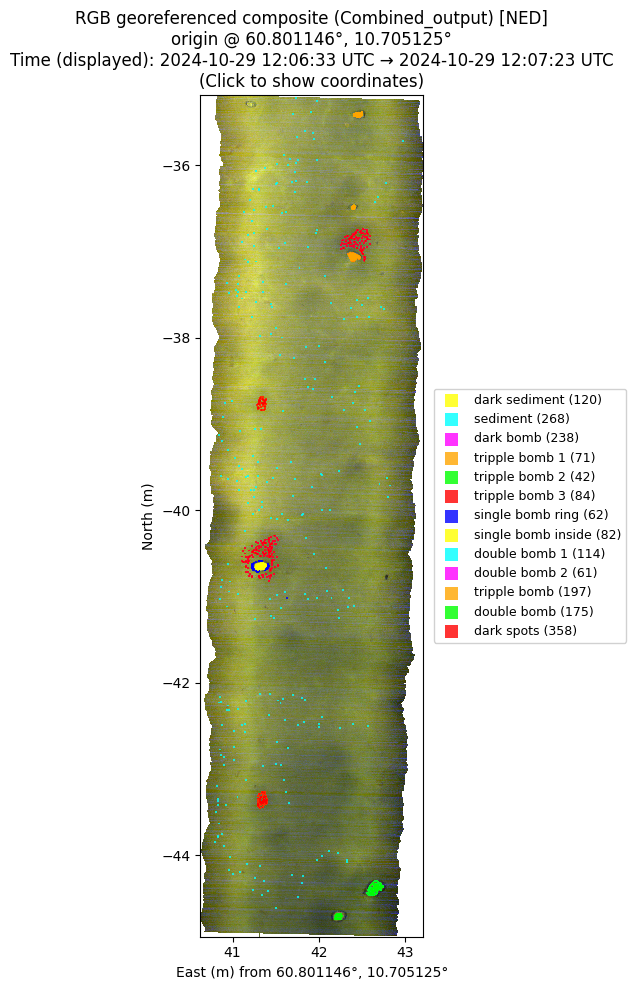

In [63]:
cube.plot_georef(
    apply_alignment_shift=True,
    use_corrected=False,
    coordinate_system="NED",
    track_start=config.UHI_TRACK_RANGE_5[0],
    track_end=config.UHI_TRACK_RANGE_5[1],
    figsize=(30, 10),
    roi_collection="all",
    roi_marker_size=2,
    roi_legend_loc="outside",
    roi_marker_edgewidth=0,
    roi_legend_markersize=40,
)

In [ ]:
%matplotlib inline

In [50]:
# All ROI spectra with std bands
cube.plot_spectrum(
    roi_names="all",
    use_corrected=True,
    wavelength_range=(475, 650),
    wavelength_smoothing=5,
)

❌ No data loaded.


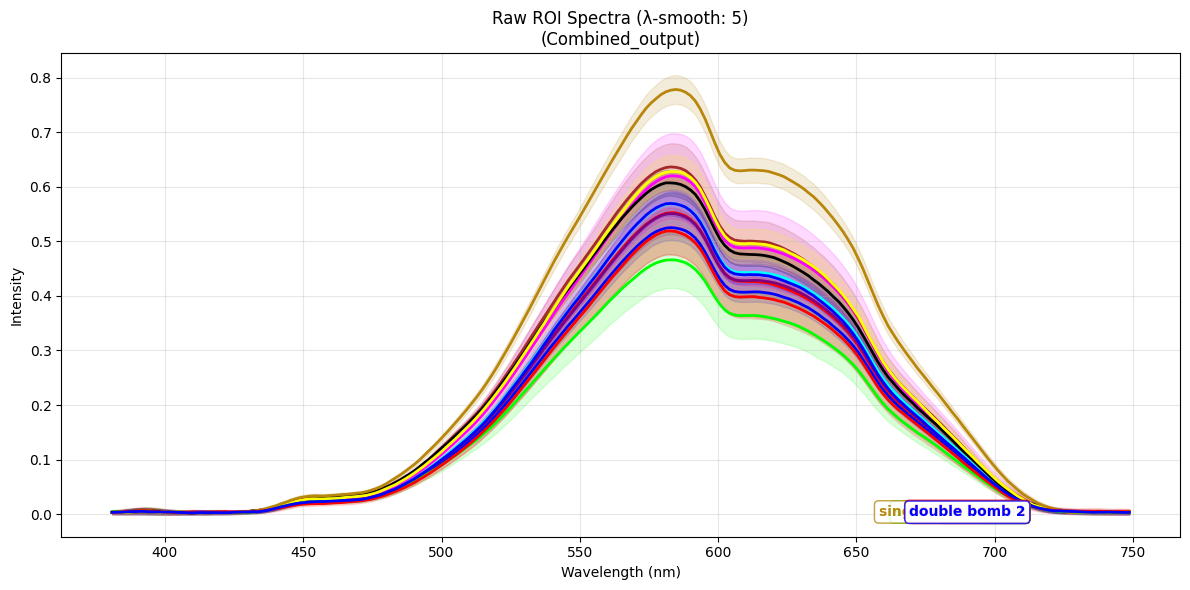

In [52]:
# All ROI spectra with std bands
cube.plot_spectrum(
    roi_names="all",
    use_corrected=False,
    # wavelength_range=(475, 650),
    wavelength_smoothing=5,
)

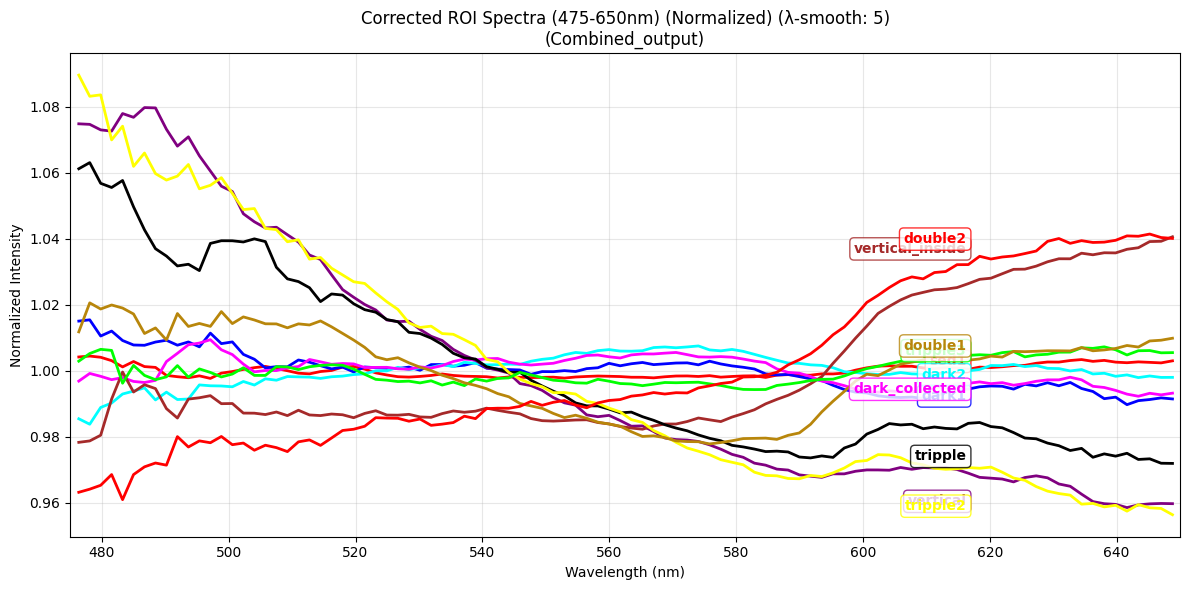

In [ ]:
# Normalized spectra (clean lines)
cube.plot_spectrum(
    roi_names="all",
    use_corrected=True,
    wavelength_range=(475, 650),
    wavelength_smoothing=5,
    normalize=True,
    show_std=False,
)

In [ ]:
# Specific ROIs only
# cube.plot_spectrum(
#     roi_names=["dark1", "dark_bomb", "sediment"],
#     use_corrected=True,
#     wavelength_range=(475, 650),
#     wavelength_smoothing=5,
#     normalize=True,
#     show_std=False,
# )

## 🔍 DIAGNOSTIC: Verify file 5 uses the good w=750 from 4+5 run